# Levelling to a grid

In [1]:
%load_ext autoreload
%autoreload 2

import bordado as bd
import boule
import cmocean
import numpy as np
import pandas as pd
import pooch
import pyproj
import verde as vd
import xarray as xr

import airbornegeo

## Load survey data

This is a subset of the BAS AGAP survey over Antarctica's Gamburtsev Subglacial Mountains. The file is download and subset in the notebook `AGAP_gravity_survey`, and the BAS processing steps are repeated in the notebook `processing_AGAP_gravity_survey`.

In [2]:
data_df = pd.read_csv("data/AGAP_gravity_survey_processed.csv")
data_df = data_df[
    [
        "easting",
        "northing",
        "height",
        "line",
        "unixtime",
        "distance_along_line",
        "grav_disturbance_filt",
    ]
]
data_df.head()

,easting,northing,height,line,unixtime,distance_along_line,grav_disturbance_filt
0,1.000024e+06,226237.330771,4156.1,1,1.229507e+09,0.000000,49.38
1,1.000083e+06,226246.631269,4156.0,1,1.229507e+09,59.842447,49.45
2,1.000142e+06,226255.809132,4156.1,1,1.229507e+09,119.693401,49.52
3,1.000201e+06,226264.969079,4156.4,1,1.229507e+09,179.545645,49.58
4,1.000260e+06,226274.156809,4156.6,1,1.229507e+09,239.285174,49.65


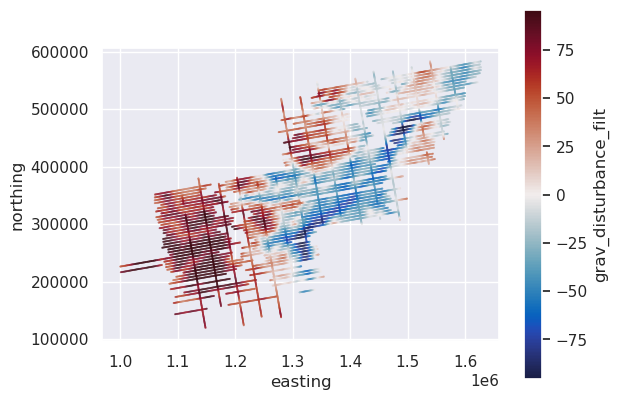

In [7]:
# plot the data
max_abs = vd.maxabs(data_df.grav_disturbance_filt, percentile=95)
ax = data_df[::20].plot.scatter(
    "easting",
    "northing",
    c="grav_disturbance_filt",
    s=0.1,
    cmap=cmocean.cm.balance,
    vmin=-max_abs,
    vmax=max_abs,
)
ax.set_aspect("equal")

## Get a grid of gravity disturbance at 10km

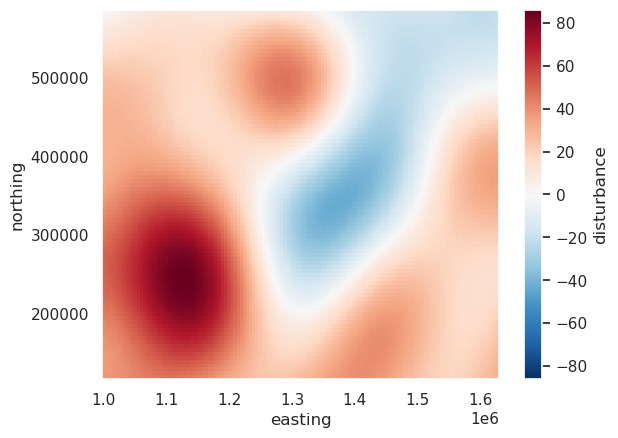

In [4]:
# Download satellite gravity data from EIGEN-6C4 model
path = pooch.retrieve(
    url="doi:10.5281/zenodo.5882207/earth-gravity-10arcmin.nc",
    known_hash="d55134501da0d984f318c0f92e1a15a8472176ec7babde5edfdb58855190273e",
    progressbar=True,
)
grid = xr.load_dataset(path)

# add height as variable
grid["ellipsoidal_height"] = xr.full_like(grid.gravity, 10e3)


# subset to geographic region of interest
region = bd.get_region((data_df.easting, data_df.northing))
region_pad = bd.pad_region(region, 20e3)
transformer = pyproj.Transformer.from_crs("epsg:3031", "epsg:4326")
region_geo = transformer.transform_bounds(
    left=region_pad[0],
    bottom=region_pad[2],
    right=region_pad[1],
    top=region_pad[3],
)
grid = grid.sel(
    latitude=slice(region_geo[0], region_geo[2]),
    longitude=slice(region_geo[1], region_geo[3]),
)


# calculated normal gravity at all EIGEN observation locations
grid["normal_gravity"] = boule.WGS84.normal_gravity(
    (None, grid.latitude, grid.ellipsoidal_height),
)

# calculate gravity disturbance
grid["disturbance"] = grid.gravity - grid.normal_gravity

# reproject to polar stereographic
eigen_disturbance = vd.project_grid(
    grid.disturbance,
    projection=pyproj.Proj("epsg:3031"),
    spacing=5e3,
    region=region,
)
eigen_disturbance.plot()

## Upward continue survey data to same height as gravity grid

In order to accurately compare the survey gravity data to the grid, the gravity data should be upward continued so it's at the same altitude.

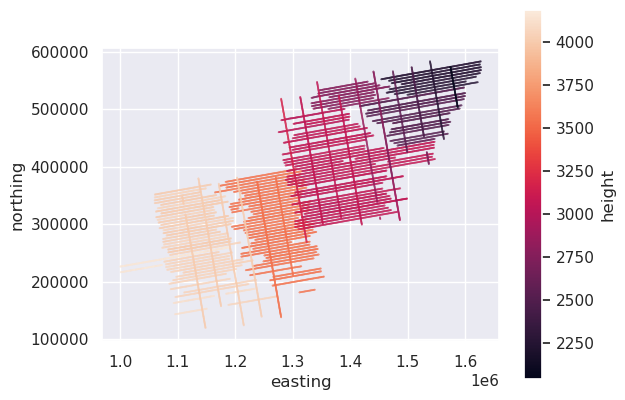

In [8]:
# plot the data
ax = data_df[::20].plot.scatter(
    "easting",
    "northing",
    c="height",
    s=0.1,
)
ax.set_aspect("equal")

In [9]:
blocked_survey = airbornegeo.block_reduce(
    data_df,
    np.median,
    spacing=1000,
    reduce_by="distance_along_line",
    groupby_column="line",
)
blocked_survey

Block-reducing segments:   0%|          | 0/100 [00:00<?, ?it/s]

,distance_along_line,tmp,easting,northing,height,line,unixtime,grav_disturbance_filt
0,477.521406,0.0,1.000496e+06,226310.158049,4159.1,1,1.229507e+09,49.89
1,1477.462561,0.0,1.001484e+06,226460.426302,4160.3,1,1.229507e+09,50.73
2,2504.019094,0.0,1.002497e+06,226630.494762,4156.0,1,1.229507e+09,51.09
3,3518.522095,0.0,1.003499e+06,226786.791629,4159.6,1,1.229507e+09,51.07
4,4528.427996,0.0,1.004498e+06,226936.380167,4165.7,1,1.229507e+09,51.43
...,...,...,...,...,...,...,...,...
21373,68170.289011,0.0,1.586103e+06,507079.737473,2049.2,100,1.230382e+09,-1.66
21374,69150.087140,0.0,1.586259e+06,506112.838506,2051.8,100,1.230382e+09,-2.58
21375,70159.126161,0.0,1.586438e+06,505120.357453,2053.1,100,1.230382e+09,-4.03
21376,71178.859535,0.0,1.586603e+06,504114.078250,2058.5,100,1.230382e+09,-5.99


In [10]:
# fit a set of equivalent sources to each line individually
eqs = airbornegeo.eq_sources_1d(
    blocked_survey,
    data_column="grav_disturbance_filt",
    depth="default",
    damping=None,
    block_size=1000,  # for speed, block reduce sources
    groupby_column="line",
)
eqs

Segments:   0%|          | 0/100 [00:00<?, ?it/s]

{1: EquivalentSources(block_size=1000),
 2: EquivalentSources(block_size=1000),
 3: EquivalentSources(block_size=1000),
 4: EquivalentSources(block_size=1000),
 5: EquivalentSources(block_size=1000),
 6: EquivalentSources(block_size=1000),
 7: EquivalentSources(block_size=1000),
 8: EquivalentSources(block_size=1000),
 9: EquivalentSources(block_size=1000),
 10: EquivalentSources(block_size=1000),
 11: EquivalentSources(block_size=1000),
 12: EquivalentSources(block_size=1000),
 13: EquivalentSources(block_size=1000),
 14: EquivalentSources(block_size=1000),
 15: EquivalentSources(block_size=1000),
 16: EquivalentSources(block_size=1000),
 17: EquivalentSources(block_size=1000),
 18: EquivalentSources(block_size=1000),
 19: EquivalentSources(block_size=1000),
 20: EquivalentSources(block_size=1000),
 21: EquivalentSources(block_size=1000),
 22: EquivalentSources(block_size=1000),
 23: EquivalentSources(block_size=1000),
 24: EquivalentSources(block_size=1000),
 25: EquivalentSources(bl

In [11]:
# upward continue each line to 10 km (height of EIGEN disturbance)
blocked_survey["upward_continued_10km"] = airbornegeo.upward_continue_by_line(
    blocked_survey,
    eqs,
    height=10e3,
    groupby_column="line",
)
blocked_survey.head()

Segments:   0%|          | 0/100 [00:00<?, ?it/s]

,distance_along_line,tmp,easting,northing,height,line,unixtime,grav_disturbance_filt,upward_continued_10km
0,477.521406,0.0,1.000496e+06,226310.158049,4159.1,1,1.229507e+09,49.89,40.232278
1,1477.462561,0.0,1.001484e+06,226460.426302,4160.3,1,1.229507e+09,50.73,40.972657
2,2504.019094,0.0,1.002497e+06,226630.494762,4156.0,1,1.229507e+09,51.09,41.713109
3,3518.522095,0.0,1.003499e+06,226786.791629,4159.6,1,1.229507e+09,51.07,42.431563
4,4528.427996,0.0,1.004498e+06,226936.380167,4165.7,1,1.229507e+09,51.43,43.141623


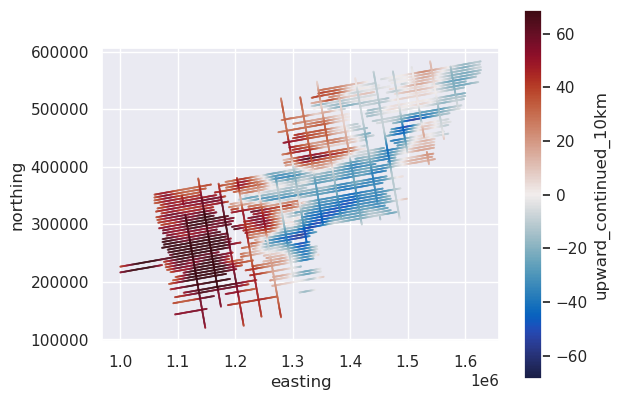

In [12]:
# plot the upward continued data
max_abs = vd.maxabs(blocked_survey.upward_continued_10km, percentile=95)
ax = blocked_survey.plot.scatter(
    "easting",
    "northing",
    c="upward_continued_10km",
    s=0.1,
    cmap=cmocean.cm.balance,
    vmin=-max_abs,
    vmax=max_abs,
)
ax.set_aspect("equal")

### Sample the satellite gravity grid values into the dataframe

In [13]:
# sample grid along lines
blocked_survey["sampled_satellite_values"] = airbornegeo.sample_grid(
    blocked_survey,
    eigen_disturbance,
    coord_names=("easting", "northing"),
)
blocked_survey.head()

,distance_along_line,tmp,easting,northing,height,line,unixtime,grav_disturbance_filt,upward_continued_10km,sampled_satellite_values
0,477.521406,0.0,1.000496e+06,226310.158049,4159.1,1,1.229507e+09,49.89,40.232278,48.933389
1,1477.462561,0.0,1.001484e+06,226460.426302,4160.3,1,1.229507e+09,50.73,40.972657,49.077294
2,2504.019094,0.0,1.002497e+06,226630.494762,4156.0,1,1.229507e+09,51.09,41.713109,49.229306
3,3518.522095,0.0,1.003499e+06,226786.791629,4159.6,1,1.229507e+09,51.07,42.431563,49.380622
4,4528.427996,0.0,1.004498e+06,226936.380167,4165.7,1,1.229507e+09,51.43,43.141623,49.533537


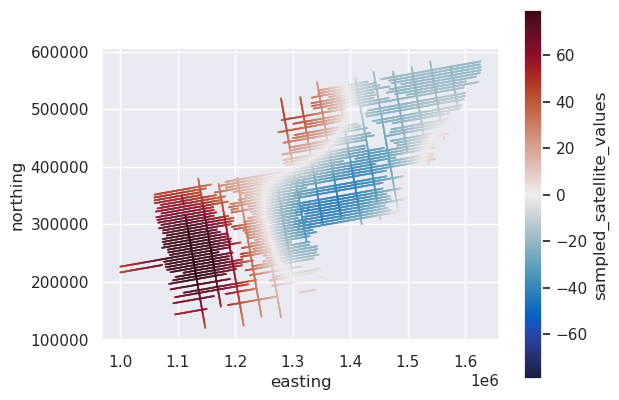

In [14]:
# plot the sampled grid values
max_abs = vd.maxabs(blocked_survey.sampled_satellite_values, percentile=95)
ax = blocked_survey.plot.scatter(
    "easting",
    "northing",
    c="sampled_satellite_values",
    s=0.1,
    cmap=cmocean.cm.balance,
    vmin=-max_abs,
    vmax=max_abs,
)
ax.set_aspect("equal")

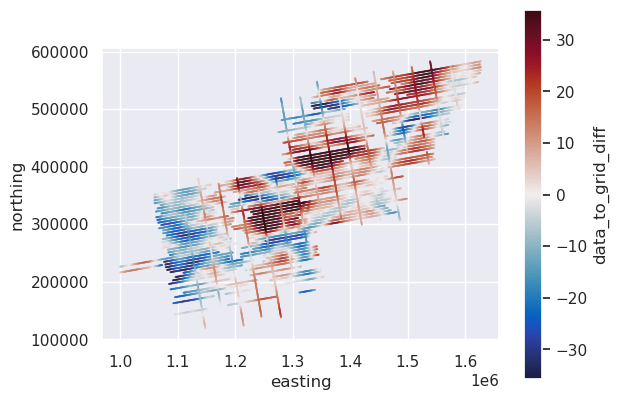

In [15]:
# plot the difference
blocked_survey["data_to_grid_diff"] = (
    blocked_survey.upward_continued_10km - blocked_survey.sampled_satellite_values
)
max_abs = vd.maxabs(blocked_survey.data_to_grid_diff, percentile=95)
ax = blocked_survey.plot.scatter(
    "easting",
    "northing",
    c="data_to_grid_diff",
    s=0.1,
    cmap=cmocean.cm.balance,
    vmin=-max_abs,
    vmax=max_abs,
)
ax.set_aspect("equal")

## Level the lines to the grid

In [16]:
blocked_survey["levelled_trend_0"] = airbornegeo.level_to_grid(
    blocked_survey,
    degree=0,  # DC shift
    fit_by_column="distance_along_line",  # fit trend to misfits based on line distance
    data_column="upward_continued_10km",
    grid_column="sampled_satellite_values",
    groupby_column="line",
)
blocked_survey.head()

,distance_along_line,tmp,easting,northing,height,line,unixtime,grav_disturbance_filt,upward_continued_10km,sampled_satellite_values,data_to_grid_diff,levelled_trend_0
0,477.521406,0.0,1.000496e+06,226310.158049,4159.1,1,1.229507e+09,49.89,40.232278,48.933389,-8.701111,42.490687
1,1477.462561,0.0,1.001484e+06,226460.426302,4160.3,1,1.229507e+09,50.73,40.972657,49.077294,-8.104637,43.231067
2,2504.019094,0.0,1.002497e+06,226630.494762,4156.0,1,1.229507e+09,51.09,41.713109,49.229306,-7.516197,43.971518
3,3518.522095,0.0,1.003499e+06,226786.791629,4159.6,1,1.229507e+09,51.07,42.431563,49.380622,-6.949059,44.689972
4,4528.427996,0.0,1.004498e+06,226936.380167,4165.7,1,1.229507e+09,51.43,43.141623,49.533537,-6.391913,45.400032


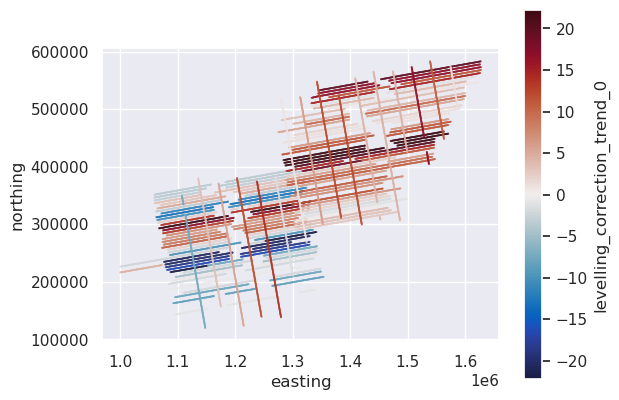

In [17]:
# plot the levelling correction
blocked_survey["levelling_correction_trend_0"] = (
    blocked_survey.upward_continued_10km - blocked_survey.levelled_trend_0
)
max_abs = vd.maxabs(blocked_survey.levelling_correction_trend_0, percentile=95)
ax = blocked_survey.plot.scatter(
    "easting",
    "northing",
    c="levelling_correction_trend_0",
    s=0.1,
    cmap=cmocean.cm.balance,
    vmin=-max_abs,
    vmax=max_abs,
)
ax.set_aspect("equal")

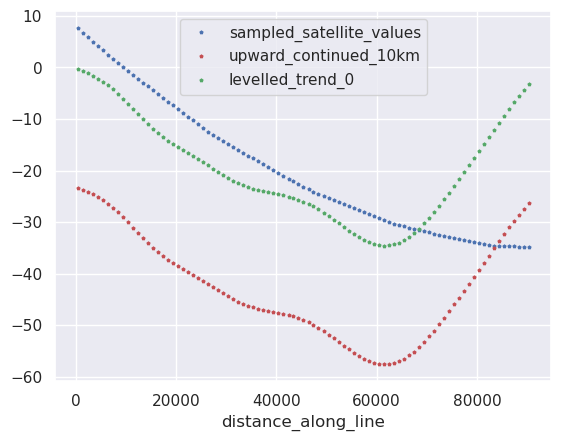

In [18]:
# look at just 1 of the leveled lines
line_df = blocked_survey[blocked_survey.line == 2]
ax = line_df.plot.line(
    "distance_along_line",
    "sampled_satellite_values",
    style="bp",
    ms=2,
)
ax = line_df.plot.line(
    "distance_along_line",
    "upward_continued_10km",
    style="rp",
    ms=2,
    ax=ax,
)
ax = line_df.plot.line(
    "distance_along_line",
    "levelled_trend_0",
    style="gp",
    ms=2,
    ax=ax,
)

## Level the entire survey to the grid

Instead of levelling each line individually to the grid, we can level the entire survey together to the grid. To do this, we don't supply the `groupby_column` argument, and choose the coordinate columns for the the `fit_by_column` argument.

In [19]:
blocked_survey["levelled_trend_1"] = airbornegeo.level_to_grid(
    blocked_survey,
    degree=1,
    fit_by_column=("easting", "northing"),  # fit trend based on coordinates
    data_column="upward_continued_10km",
    grid_column="sampled_satellite_values",
)
blocked_survey["levelled_trend_2"] = airbornegeo.level_to_grid(
    blocked_survey,
    degree=2,
    fit_by_column=("easting", "northing"),  # fit trend based on coordinates
    data_column="upward_continued_10km",
    grid_column="sampled_satellite_values",
)
blocked_survey.head()

,distance_along_line,tmp,easting,northing,height,line,unixtime,grav_disturbance_filt,upward_continued_10km,sampled_satellite_values,data_to_grid_diff,levelled_trend_0,levelling_correction_trend_0,levelled_trend_1,levelled_trend_2
0,477.521406,0.0,1.000496e+06,226310.158049,4159.1,1,1.229507e+09,49.89,40.232278,48.933389,-8.701111,42.490687,-2.258409,47.864111,67.211414
1,1477.462561,0.0,1.001484e+06,226460.426302,4160.3,1,1.229507e+09,50.73,40.972657,49.077294,-8.104637,43.231067,-2.258409,48.572771,67.732883
2,2504.019094,0.0,1.002497e+06,226630.494762,4156.0,1,1.229507e+09,51.09,41.713109,49.229306,-7.516197,43.971518,-2.258409,49.280465,68.250944
3,3518.522095,0.0,1.003499e+06,226786.791629,4159.6,1,1.229507e+09,51.07,42.431563,49.380622,-6.949059,44.689972,-2.258409,49.966691,68.749212
4,4528.427996,0.0,1.004498e+06,226936.380167,4165.7,1,1.229507e+09,51.43,43.141623,49.533537,-6.391913,45.400032,-2.258409,50.644744,69.240270


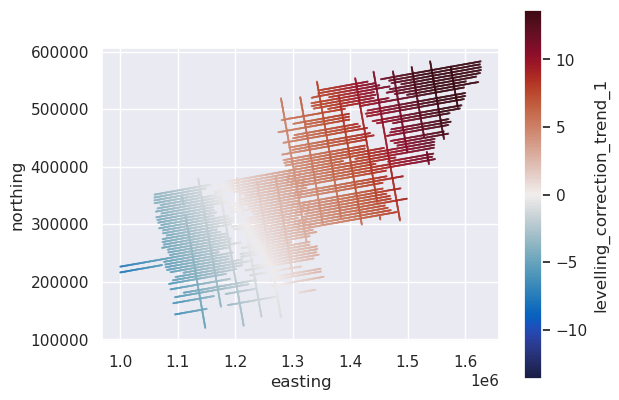

In [20]:
# plot the levelling correction
blocked_survey["levelling_correction_trend_1"] = (
    blocked_survey.upward_continued_10km - blocked_survey.levelled_trend_1
)
max_abs = vd.maxabs(blocked_survey.levelling_correction_trend_1, percentile=95)
ax = blocked_survey.plot.scatter(
    "easting",
    "northing",
    c="levelling_correction_trend_1",
    s=0.1,
    cmap=cmocean.cm.balance,
    vmin=-max_abs,
    vmax=max_abs,
)
ax.set_aspect("equal")

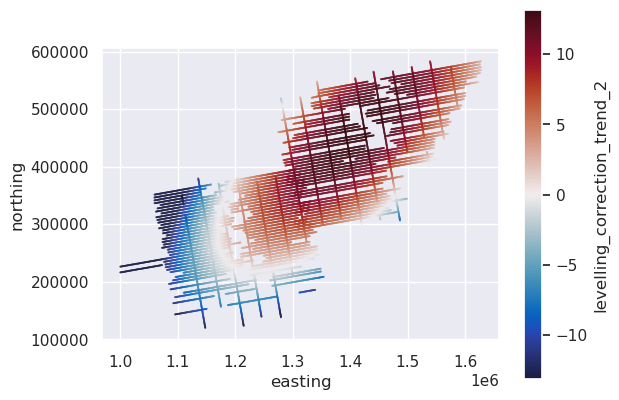

In [21]:
# plot the levelling correction
blocked_survey["levelling_correction_trend_2"] = (
    blocked_survey.upward_continued_10km - blocked_survey.levelled_trend_2
)
max_abs = vd.maxabs(blocked_survey.levelling_correction_trend_2, percentile=95)
ax = blocked_survey.plot.scatter(
    "easting",
    "northing",
    c="levelling_correction_trend_2",
    s=0.1,
    cmap=cmocean.cm.balance,
    vmin=-max_abs,
    vmax=max_abs,
)
ax.set_aspect("equal")